In [1]:
import os

if os.getcwd().endswith('/notebooks'):
    os.chdir('..')
print(os.getcwd())

/home/cmcouto-silva/Projects/gitlab/sql-dependency-extractor


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [3]:
# See all possibilites at https://matplotlib.org/stable/users/explain/customizing.html
sns.set_theme(
    context='talk', style='ticks', font_scale=.8,
    rc={
      'figure.figsize': (15,6),
      'font.weight': 'regular', 'axes.labelpad': 10, 'axes.titlepad': 20,
      'ytick.labelsize': 'small', 'xtick.labelsize': 'small',
      'axes.grid':True, 'grid.alpha':.2
    }
)

In [4]:
SUMMARY_PATH = "outputs/20250221/summary.csv"

In [5]:
df_summary = pd.read_csv(SUMMARY_PATH)
df_summary.columns

Index(['framework', 'model', 'prompt', 'all_exact_match', 'exact_match_pct',
       'all_tbl_in_cols', 'tbl_in_cols_pct', 'tbl_recall_avg',
       'tbl_precision_avg', 'tbl_f1_avg', 'col_recall_avg',
       'col_precision_avg', 'col_f1_avg', 'avg_exec_time', 'input_price',
       'output_price', 'avg_price', 'total_price'],
      dtype='object')

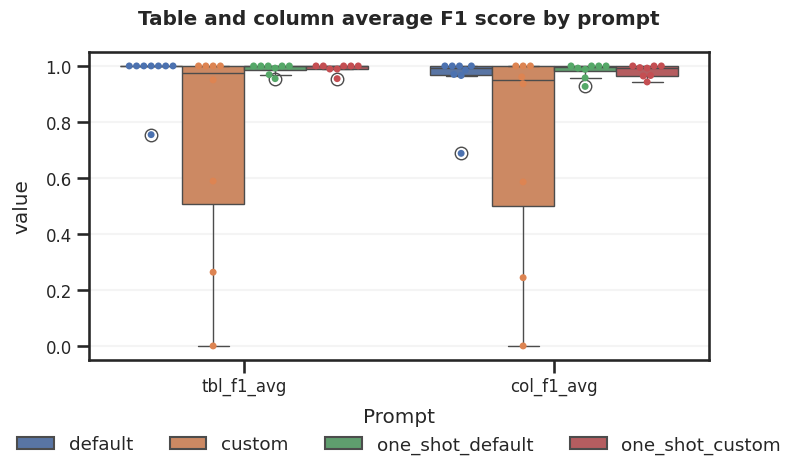

In [6]:
prompt_plot_order = ['default', 'custom', 'one_shot_default', 'one_shot_custom']

df_pivot = df_summary.melt(id_vars=['prompt'], value_vars=['tbl_f1_avg', 'col_f1_avg'])

fig,ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df_pivot, x='variable', y='value', hue='prompt', hue_order=prompt_plot_order, ax=ax)
sns.swarmplot(data=df_pivot, x='variable', y='value', hue='prompt', legend=False, hue_order=prompt_plot_order, dodge=True, ax=ax)

plt.legend(title='Prompt', bbox_to_anchor=(0.5, -0.1), loc='upper center', ncol=4, frameon=False)
plt.title('Table and column average F1 score by prompt', weight='bold')
plt.xlabel(None)

plt.show()


/tmp/ipykernel_344683/1076126671.py:8: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(
/tmp/ipykernel_344683/1076126671.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([new_labels[label.get_text()] for label in ax1.get_xticklabels()])
/tmp/ipykernel_344683/1076126671.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_344683/1076126671.py:55: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.violinplot(


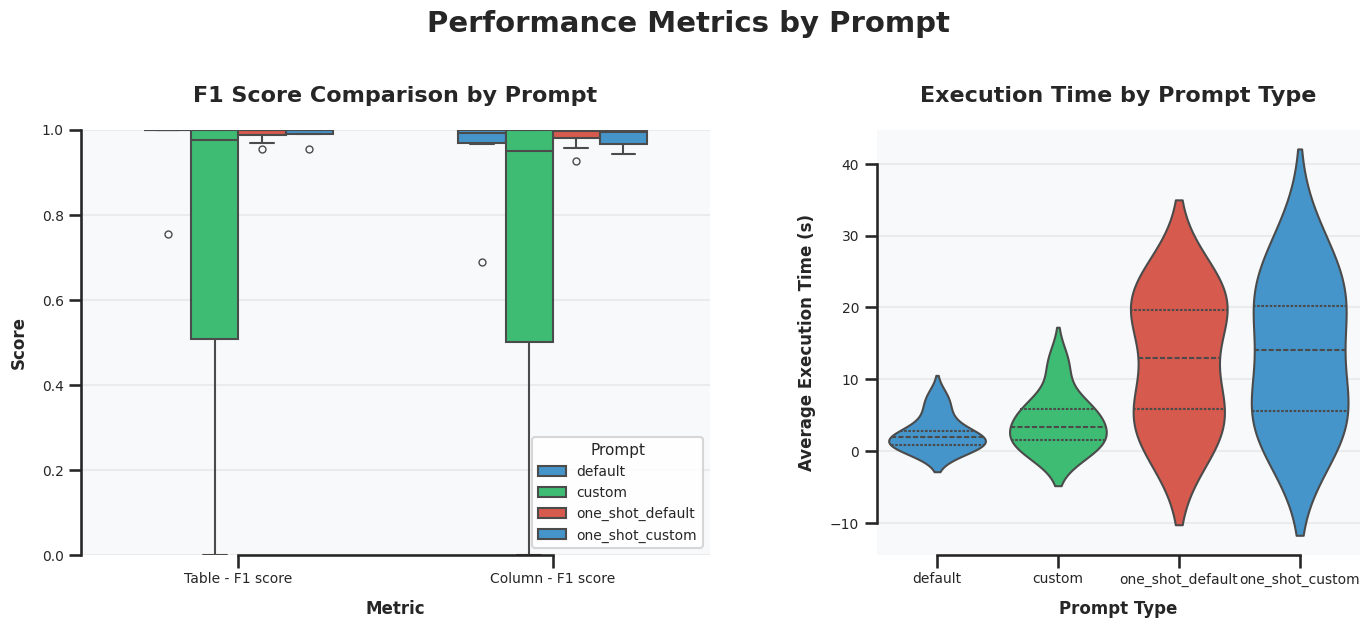

In [7]:
# Set up the figure with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1.3, 1]})

# Color palette for both plots
colors = ['#3498db', '#2ecc71', '#e74c3c']  # Blue, green, red

# 1. LEFT PLOT: F1 Score Boxplot
sns.boxplot(
    data=df_pivot, 
    x='variable', 
    y='value', 
    hue='prompt',
    hue_order=prompt_plot_order,
    width=0.6,
    linewidth=1.5,
    fliersize=5,
    saturation=0.8,
    palette=colors,
    dodge=True,
    ax=ax1
)

# Customize the left plot appearance
ax1.set_xlabel('Metric', fontsize=12, fontweight='bold')
ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('F1 Score Comparison by Prompt', fontsize=16, fontweight='bold')

# Rename the x-axis labels for clarity
new_labels = {'tbl_f1_avg': 'Table - F1 score', 'col_f1_avg': 'Column - F1 score'}
ax1.set_xticklabels([new_labels[label.get_text()] for label in ax1.get_xticklabels()])

# Add a subtle grid for better readability
ax1.grid(axis='y', alpha=0.3)

# Move the legend to a better position and style it
ax1.legend(
    title='Prompt',
    title_fontsize=11,
    fontsize=10,
    loc='lower right',
    frameon=True,
    framealpha=0.9,
    edgecolor='lightgray'
)

# Set y-axis limits to show all data with padding
y_min, y_max = ax1.get_ylim()
padding = (y_max - y_min) * 0.1  # 10% padding
ax1.set_ylim(max(0, y_min - padding), min(1.0, y_max + padding))

# Add background color
ax1.set_facecolor('#f8f9fa')

# 2. RIGHT PLOT: Execution Time Violin Plot
sns.violinplot(
    data=df_summary, 
    x='prompt', 
    y='avg_exec_time', 
    order=prompt_plot_order,
    palette=colors,
    inner='quartile',  # Show quartile lines inside violins
    linewidth=1.5,
    saturation=0.8,
    ax=ax2
)

# Customize the right plot appearance
ax2.set_xlabel('Prompt Type', fontsize=12, fontweight='bold')
ax2.set_ylabel('Average Execution Time (s)', fontsize=12, fontweight='bold')
ax2.set_title('Execution Time by Prompt Type', fontsize=16, fontweight='bold')

# # Set nicer x-axis labels
# prompt_labels = {'default': 'Default', 'custom_prompt': 'Custom', 'one_shot': 'One-Shot'}
# ax2.set_xticklabels([prompt_labels[label.get_text()] for label in ax2.get_xticklabels()])

# Add a subtle grid
ax2.grid(axis='y', alpha=0.3)

# Add background color to match
ax2.set_facecolor('#f8f9fa')

# Apply to both subplots
for ax in [ax1, ax2]:
    sns.despine(ax=ax, trim=True)
    ax.tick_params(axis='both', labelsize=10)

# Overall layout adjustments
plt.suptitle('Performance Metrics by Prompt', fontsize=21, fontweight='bold', y=1.05)
plt.tight_layout()
plt.subplots_adjust(top=0.85, wspace=0.3)

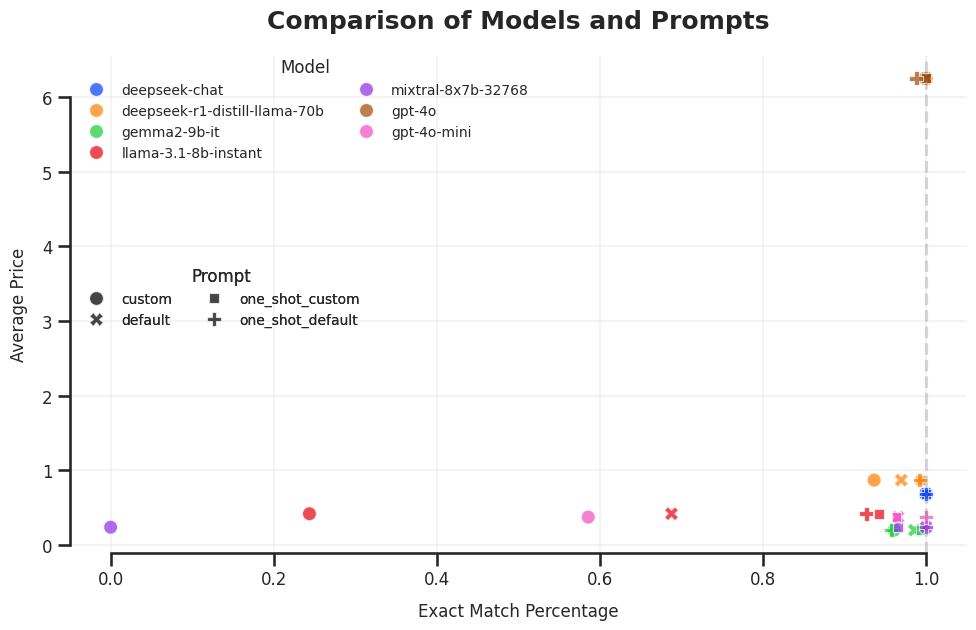

In [8]:
mask = df_summary.model.str.contains('versatile')

# Create a figure with a custom layout using gridspec
fig = plt.figure(figsize=(10, 8))
# Two rows: one for the plot + model legend (larger), one for the prompt legend (smaller)
gs = gridspec.GridSpec(2, 1, height_ratios=[0.8, 0.2])  # 2 rows: plot + model legend, prompt legend

# Create the scatter plot in the top row
ax = plt.subplot(gs[0])
sns.scatterplot(
    data=df_summary[~mask],
    x='col_f1_avg',
    y='avg_price',
    hue='model',
    style='prompt',
    s=100,  # Increase marker size
    palette='bright',  # Use a nice color palette for models
    alpha=.7,
    ax=ax,
)

# Add a vertical line
ax.axvline(1, alpha=.3, ls='--', color='gray')

# Remove the default legend (since we're creating custom ones)
ax.get_legend().remove()

# Add labels and title
ax.set_xlabel('Exact Match Percentage', fontsize=12)
ax.set_ylabel('Average Price', fontsize=12)
ax.set_title('Comparison of Models and Prompts', weight='bold', fontsize=18, pad=20)

# Get all handles and labels
handles, labels = ax.get_legend_handles_labels()

# Separate handles and labels for 'model' and 'prompt'
model_handles = []
model_labels = []
prompt_handles = []
prompt_labels = []

# Iterate through handles and labels to separate them
for handle, label in zip(handles, labels):
    if label in df_summary['model'].unique():
        model_handles.append(handle)
        model_labels.append(label)
    elif label in df_summary['prompt'].unique():
        prompt_handles.append(handle)
        prompt_labels.append(label)

# Create a custom legend for 'model' (hue) in the upper-left corner of the plot
model_legend = ax.legend(
    handles=model_handles,
    labels=model_labels,
    loc='upper left',  # Anchor point of the legend
    bbox_to_anchor=(0, 1.02),  # Position in the upper-left corner
    ncol=2,  # Break into two columns
    title='Model',
    frameon=False,  # Remove legend frame
    fontsize=10,  # Adjust font size
)
plt.setp(model_legend.get_title(), fontsize=12)  # Adjust legend title size

# Create a custom legend for 'prompt' (style) inside the plot, lower-left corner
prompt_legend = ax.legend(
    handles=prompt_handles,
    labels=prompt_labels,
    loc='upper left',  # Anchor point of the legend
    bbox_to_anchor=(.0, .6),  # Position in the lower-left corner
    ncol=2,  # Break into two columns
    title='Prompt',
    frameon=False,  # Remove legend frame
    fontsize=10,  # Adjust font size
    # handletextpad=0.5,  # Adjust spacing between marker and text
    # markerscale=1.5,  # Increase marker size in the legend
)
plt.setp(prompt_legend.get_title(), fontsize=12)  # Adjust legend title size

# Ensure the 'prompt' legend uses black colors
for handle in prompt_legend.legend_handles:
    handle.set_color('black')

# Add the legends back to the plot
ax.add_artist(model_legend)
ax.add_artist(prompt_legend)

sns.despine(trim=True)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

In [9]:
models_acc = df_summary.groupby('model').all_exact_match.all()
models_with_full_acc = models_acc[models_acc]
print(models_with_full_acc)

model
deepseek-chat              True
llama-3.3-70b-versatile    True
Name: all_exact_match, dtype: bool


In [10]:
model_prompt_acc = df_summary.groupby(['model','prompt']).all_exact_match.all()
model_prompt_with_full_acc = model_prompt_acc.to_frame()[model_prompt_acc]
display(model_prompt_with_full_acc)

all_exact_match
model                   prompt                           
deepseek-chat           custom                       True
                        default                      True
                        one_shot_custom              True
                        one_shot_default             True
gpt-4o                  custom                       True
                        default                      True
                        one_shot_custom              True
llama-3.3-70b-versatile custom                       True
                        default                      True
                        one_shot_custom              True
                        one_shot_default             True
mixtral-8x7b-32768      default                      True
                        one_shot_default             True

# Explore Visipec Results

In [11]:
# Load data
df = pd.read_csv('~/Downloads/artifacts (1)/artifacts/web_import_function_defs_deps.csv')
df.head()

,function_name,function_def,sqldeps
0,import_data,CREATE OR REPLACE FUNCTION web_import.import_d...,"{'tables': ['public.Embargo', 'public.Embargo_..."
1,postgres_fdw_handler,CREATE OR REPLACE FUNCTION web_import.postgres...,"{'tables': [], 'columns': {}}"
2,postgres_fdw_validator,CREATE OR REPLACE FUNCTION web_import.postgres...,"{'tables': [], 'columns': {}}"
3,build_Api_Property_Defor,"CREATE OR REPLACE FUNCTION web_import.""build_A...","{'tables': ['build_public.Property_Shape', 'bu..."
4,build_Api_Property_Embargo,"CREATE OR REPLACE FUNCTION web_import.""build_A...","{'tables': ['build_public.Embargo', 'build_pub..."


In [12]:
def get_tbl_col_relationships(x):
    cols = eval(x)['columns']
    return [(k,value) for k,values in cols.items() for value in values]

df.sqldeps.map(lambda x: get_tbl_col_relationships(x)).explode().value_counts().head(5)

sqldeps
(build_public.Transaction_Property, TransactionId)    10
(build_public.Transaction_Property, PropertyId)       10
(build_public.Transaction_Property, RoleId)            9
(build_public.Transaction, Id)                         9
(build_public.Transaction, Status)                     8
Name: count, dtype: int64

In [13]:
df_relationships = (
    df.sqldeps.map(lambda x: get_tbl_col_relationships(x))
    .explode()
    .value_counts()
    .reset_index()
)

df_relationships.columns = ['table_column', 'count']

# Split the tuple into separate 'table' and 'column' columns
df_relationships[['table', 'column']] = df_relationships['table_column'].apply(pd.Series)

# Split 'table' into 'schema' and 'table' based on the first dot
df_relationships[['schema', 'table']] = df_relationships['table'].str.split('.', n=1, expand=True)

# Drop the original combined columns
df_relationships.drop(columns=['table_column'], inplace=True)

print(df_relationships.head(5).set_index(['schema','table','column']).reset_index(level=[1,2]).to_markdown())

| schema       | table                | column        |   count |
|:-------------|:---------------------|:--------------|--------:|
| build_public | Transaction_Property | TransactionId |      10 |
| build_public | Transaction_Property | PropertyId    |      10 |
| build_public | Transaction_Property | RoleId        |       9 |
| build_public | Transaction          | Id            |       9 |
| build_public | Transaction          | Status        |       8 |


In [14]:
df_tbl = (
    df.sqldeps.map(lambda x: eval(x)['tables'])
    .explode()
    .value_counts()
    .head(5)
    .to_frame(name='count')
    .reset_index()
)

df_tbl[['schema', 'table']] = df_tbl.iloc[:, 0].str.split('.', n=1, expand=True)
df_tbl.drop(columns=df_tbl.columns[0], inplace=True)

print(df_tbl.set_index(['schema','table']).reset_index(level=1).to_markdown())

| schema       | table                     |   count |
|:-------------|:--------------------------|--------:|
| build_public | Transaction_Property      |      10 |
| build_public | Transaction               |       9 |
| build_import | FileRegistry              |       7 |
| build_public | Embargo                   |       6 |
| web_import   | Api_Slaughterhouse_Lookup |       5 |
